# Formula 1 Driver Performance Index (5 Seasons)

## Project aim
Build a composite **F1 Driver Performance Index** that compares drivers across the **last 5 completed seasons**.

## Notebook structure
1. Setup and imports
2. Download race and qualifying data for 5 seasons
3. Build clean event-level datasets
4. Aggregate to driver-season level
5. Handle missing data
6. Multivariate analysis
7. Normalisation
8. Weighting and aggregation
9. Compare with official standings
10. Visualisation
11. Export final outputs
12. Reflection, struggles, references, and commit log


In [2]:
import json
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Data Setup

In [3]:
BASE_URL = 'https://api.jolpi.ca/ergast/f1'
SEASONS = [2021, 2022, 2023, 2024, 2025]

DATA_DIR = Path('data')
RAW_DIR = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_DIR = Path('outputs')

for directory in [RAW_DIR, PROCESSED_DIR, OUTPUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SEASONS

[2021, 2022, 2023, 2024, 2025]

## 2. Download data

In [4]:
def fetch_json(endpoint):
    url = f"{BASE_URL}/{endpoint}"
    
    response = requests.get(url, timeout=30)
    
    if response.status_code == 429:
        print("Rate limited. Waiting 2 seconds...")
        time.sleep(2)
        response = requests.get(url, timeout=30)
    
    response.raise_for_status()
    
    # small delay to avoid hitting limit
    time.sleep(0.3)
    
    return response.json()


def get_rounds_for_season(season: int) -> list[int]:
    data = fetch_json(f'{season}.json')
    races = data['MRData']['RaceTable']['Races']
    return [int(r['round']) for r in races]

In [5]:

def build_race_rows(data: dict[str, Any]) -> list[dict[str, Any]]:
    races = data['MRData']['RaceTable']['Races']
    rows = []

    for race in races:
        for result in race.get('Results', []):
            driver = result['Driver']
            constructor = result['Constructor']

            rows.append({
                'season': int(race['season']),
                'round': int(race['round']),
                'race_name': race['raceName'],
                'date': race.get('date'),
                'driver_id': driver['driverId'],
                'driver_code': driver.get('code', ''),
                'driver_name': f"{driver['givenName']} {driver['familyName']}",
                'constructor': constructor['name'],
                'grid': pd.to_numeric(result.get('grid'), errors='coerce'),
                'finish_position': pd.to_numeric(result.get('position'), errors='coerce'),
                'points': pd.to_numeric(result.get('points'), errors='coerce'),
                'status': result.get('status', '')
            })

    return rows


def build_quali_rows(data: dict[str, Any]) -> list[dict[str, Any]]:
    races = data['MRData']['RaceTable']['Races']
    rows = []

    for race in races:
        for result in race.get('QualifyingResults', []):
            driver = result['Driver']
            constructor = result['Constructor']

            rows.append({
                'season': int(race['season']),
                'round': int(race['round']),
                'race_name': race['raceName'],
                'date': race.get('date'),
                'driver_id': driver['driverId'],
                'driver_code': driver.get('code', ''),
                'driver_name': f"{driver['givenName']} {driver['familyName']}",
                'constructor': constructor['name'],
                'quali_position': pd.to_numeric(result.get('position'), errors='coerce'),
                'q1': result.get('Q1'),
                'q2': result.get('Q2'),
                'q3': result.get('Q3')
            })

    return rows

In [11]:
all_race_rows = []
all_quali_rows = []

for season in SEASONS:
    rounds = get_rounds_for_season(season)
    print(f"Season {season}: {len(rounds)} rounds found")

    for rnd in rounds:
        race_json = fetch_json(f"{season}/{rnd}/results.json")
        quali_json = fetch_json(f"{season}/{rnd}/qualifying.json")

        all_race_rows.extend(build_race_rows(race_json))
        all_quali_rows.extend(build_quali_rows(quali_json))

race_df = pd.DataFrame(all_race_rows)
quali_df = pd.DataFrame(all_quali_rows)

race_df.to_csv(RAW_DIR / "race_results_2021_2025.csv", index=False)
quali_df.to_csv(RAW_DIR / "qualifying_results_2021_2025.csv", index=False)

print("\nRace dataset shape:", race_df.shape)
print("Qualifying dataset shape:", quali_df.shape)

print("\nRace data preview:")
display(race_df.head())

print("\nQualifying data preview:")
display(quali_df.head())

Season 2021: 22 rounds found
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 seconds...
Rate limited. Waiting 2 se

,season,round,race_name,date,driver_id,driver_code,driver_name,constructor,grid,finish_position,points,status
0,2021,1,Bahrain Grand Prix,2021-03-28,hamilton,HAM,Lewis Hamilton,Mercedes,2,1,25.0,Finished
1,2021,1,Bahrain Grand Prix,2021-03-28,max_verstappen,VER,Max Verstappen,Red Bull,1,2,18.0,Finished
2,2021,1,Bahrain Grand Prix,2021-03-28,bottas,BOT,Valtteri Bottas,Mercedes,3,3,16.0,Finished
3,2021,1,Bahrain Grand Prix,2021-03-28,norris,NOR,Lando Norris,McLaren,7,4,12.0,Finished
4,2021,1,Bahrain Grand Prix,2021-03-28,perez,PER,Sergio Pérez,Red Bull,0,5,10.0,Finished



Qualifying data preview:


,season,round,race_name,date,driver_id,driver_code,driver_name,constructor,quali_position,q1,q2,q3
0,2021,1,Bahrain Grand Prix,2021-03-28,max_verstappen,VER,Max Verstappen,Red Bull,1,1:30.499,1:30.318,1:28.997
1,2021,1,Bahrain Grand Prix,2021-03-28,hamilton,HAM,Lewis Hamilton,Mercedes,2,1:30.617,1:30.085,1:29.385
2,2021,1,Bahrain Grand Prix,2021-03-28,bottas,BOT,Valtteri Bottas,Mercedes,3,1:31.200,1:30.186,1:29.586
3,2021,1,Bahrain Grand Prix,2021-03-28,leclerc,LEC,Charles Leclerc,Ferrari,4,1:30.691,1:30.010,1:29.678
4,2021,1,Bahrain Grand Prix,2021-03-28,gasly,GAS,Pierre Gasly,AlphaTauri,5,1:30.848,1:30.513,1:29.809


## 3. EVENT-LEVEL FEATURE ENGINEERING

In [12]:
race_df["is_win"] = (race_df["finish_position"] == 1).astype(int)

race_df["is_podium"] = race_df["finish_position"].isin([1, 2, 3]).astype(int)

race_df["is_top10"] = race_df["finish_position"].between(1, 10, inclusive="both").fillna(False).astype(int)

race_df["is_dnf"] = (~race_df["status"].str.contains("Finished", case=False, na=False)).astype(int)

race_df["positions_gained"] = race_df["grid"] - race_df["finish_position"]

race_df.head()

,season,round,race_name,date,driver_id,driver_code,driver_name,constructor,grid,finish_position,points,status,is_win,is_podium,is_top10,is_dnf,positions_gained
0,2021,1,Bahrain Grand Prix,2021-03-28,hamilton,HAM,Lewis Hamilton,Mercedes,2,1,25.0,Finished,1,1,1,0,1
1,2021,1,Bahrain Grand Prix,2021-03-28,max_verstappen,VER,Max Verstappen,Red Bull,1,2,18.0,Finished,0,1,1,0,-1
2,2021,1,Bahrain Grand Prix,2021-03-28,bottas,BOT,Valtteri Bottas,Mercedes,3,3,16.0,Finished,0,1,1,0,0
3,2021,1,Bahrain Grand Prix,2021-03-28,norris,NOR,Lando Norris,McLaren,7,4,12.0,Finished,0,0,1,0,3
4,2021,1,Bahrain Grand Prix,2021-03-28,perez,PER,Sergio Pérez,Red Bull,0,5,10.0,Finished,0,0,1,0,-5


## 4. DRIVER-SEASON AGGREGATION

In [13]:
race_summary = (
    race_df.groupby(
        ["season", "driver_id", "driver_code", "driver_name", "constructor"],
        dropna=False
    )
    .agg(
        races=("round", "count"),
        total_points=("points", "sum"),
        points_per_race=("points", "mean"),
        average_finish_position=("finish_position", "mean"),
        finish_position_std=("finish_position", "std"),
        wins=("is_win", "sum"),
        podiums=("is_podium", "sum"),
        top10_finishes=("is_top10", "sum"),
        dnfs=("is_dnf", "sum"),
        dnf_rate=("is_dnf", "mean"),
        average_positions_gained=("positions_gained", "mean")
    )
    .reset_index()
)

race_summary["top10_rate"] = race_summary["top10_finishes"] / race_summary["races"]
race_summary["podium_rate"] = race_summary["podiums"] / race_summary["races"]
race_summary["win_rate"] = race_summary["wins"] / race_summary["races"]

print(race_summary.shape)
race_summary.head()

(113, 19)


,season,driver_id,driver_code,driver_name,constructor,races,total_points,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_finishes,dnfs,dnf_rate,average_positions_gained,top10_rate,podium_rate,win_rate
0,2021,alonso,ALO,Fernando Alonso,Alpine F1 Team,22,81.0,3.681818,9.909091,4.417596,0,1,15,11,0.500000,0.590909,0.681818,0.045455,0.000000
1,2021,bottas,BOT,Valtteri Bottas,Mercedes,22,219.0,9.954545,7.409091,6.344545,1,11,15,5,0.227273,-1.818182,0.681818,0.500000,0.045455
2,2021,gasly,GAS,Pierre Gasly,AlphaTauri,22,110.0,5.000000,9.363636,5.323313,0,1,15,9,0.409091,-3.000000,0.681818,0.045455,0.000000
3,2021,giovinazzi,GIO,Antonio Giovinazzi,Alfa Romeo,22,3.0,0.136364,13.090909,2.044949,0,0,2,18,0.818182,-0.272727,0.090909,0.000000,0.000000
4,2021,hamilton,HAM,Lewis Hamilton,Mercedes,22,385.5,17.522727,3.409091,4.349703,8,17,20,1,0.045455,-0.318182,0.909091,0.772727,0.363636


## 5. QUALIFYING AGGREGATION

In [14]:
quali_summary = (
    quali_df.groupby(
        ["season", "driver_id", "driver_code", "driver_name", "constructor"],
        dropna=False
    )
    .agg(
        average_qualifying_position=("quali_position", "mean")
    )
    .reset_index()
)

print(quali_summary.shape)
quali_summary.head()

(113, 6)


,season,driver_id,driver_code,driver_name,constructor,average_qualifying_position
0,2021,alonso,ALO,Fernando Alonso,Alpine F1 Team,11.000000
1,2021,bottas,BOT,Valtteri Bottas,Mercedes,3.772727
2,2021,gasly,GAS,Pierre Gasly,AlphaTauri,6.818182
3,2021,giovinazzi,GIO,Antonio Giovinazzi,Alfa Romeo,14.045455
4,2021,hamilton,HAM,Lewis Hamilton,Mercedes,2.136364


## 6. COMBINED DRIVER-SEASON DATASET

In [15]:
driver_season_df = race_summary.merge(
    quali_summary,
    on=["season", "driver_id", "driver_code", "driver_name", "constructor"],
    how="left"
)

numeric_cols = driver_season_df.select_dtypes(include=['number']).columns
driver_season_df[numeric_cols] = driver_season_df[numeric_cols].round(3)

print(driver_season_df.shape)
driver_season_df.head()

(113, 20)


,season,driver_id,driver_code,driver_name,constructor,races,total_points,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_finishes,dnfs,dnf_rate,average_positions_gained,top10_rate,podium_rate,win_rate,average_qualifying_position
0,2021,alonso,ALO,Fernando Alonso,Alpine F1 Team,22,81.0,3.682,9.909,4.418,0,1,15,11,0.500,0.591,0.682,0.045,0.000,11.000
1,2021,bottas,BOT,Valtteri Bottas,Mercedes,22,219.0,9.955,7.409,6.345,1,11,15,5,0.227,-1.818,0.682,0.500,0.045,3.773
2,2021,gasly,GAS,Pierre Gasly,AlphaTauri,22,110.0,5.000,9.364,5.323,0,1,15,9,0.409,-3.000,0.682,0.045,0.000,6.818
3,2021,giovinazzi,GIO,Antonio Giovinazzi,Alfa Romeo,22,3.0,0.136,13.091,2.045,0,0,2,18,0.818,-0.273,0.091,0.000,0.000,14.045
4,2021,hamilton,HAM,Lewis Hamilton,Mercedes,22,385.5,17.523,3.409,4.350,8,17,20,1,0.045,-0.318,0.909,0.773,0.364,2.136


## 7. MISSING DATA CHECK

In [16]:
missing_summary = driver_season_df.isna().sum().sort_values(ascending=False)
missing_summary

finish_position_std            3
season                         0
podiums                        0
win_rate                       0
podium_rate                    0
top10_rate                     0
average_positions_gained       0
dnf_rate                       0
dnfs                           0
top10_finishes                 0
wins                           0
driver_id                      0
average_finish_position        0
points_per_race                0
total_points                   0
races                          0
constructor                    0
driver_name                    0
driver_code                    0
average_qualifying_position    0
dtype: int64

## 7.1 HANDLE MISSING DATA


In [17]:
numeric_cols = driver_season_df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if driver_season_df[col].isna().sum() > 0:
        driver_season_df[col] = driver_season_df[col].fillna(driver_season_df[col].median())

driver_season_df.isna().sum()

season                         0
driver_id                      0
driver_code                    0
driver_name                    0
constructor                    0
races                          0
total_points                   0
points_per_race                0
average_finish_position        0
finish_position_std            0
wins                           0
podiums                        0
top10_finishes                 0
dnfs                           0
dnf_rate                       0
average_positions_gained       0
top10_rate                     0
podium_rate                    0
win_rate                       0
average_qualifying_position    0
dtype: int64

## 8. SAVE PROCESSED DATA

In [18]:
from pathlib import Path

processed_dir = Path("data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

driver_season_df.to_csv(processed_dir / "driver_season_summary.csv", index=False)

print("Saved:", processed_dir / "driver_season_summary.csv")

Saved: data\processed\driver_season_summary.csv


## 9. MULTIVARIATE ANALYSIS - CORRELATION

### 9.1. CORRELATION ANALYSIS

In [19]:
feature_cols = [
    'points_per_race',
    'average_finish_position',
    'finish_position_std',
    'wins',
    'podiums',
    'top10_rate',
    'dnf_rate',
    'average_positions_gained',
    'average_qualifying_position'
]

X = driver_season_df[feature_cols]

corr = X.corr()
corr_rounded = corr.round(3)
corr_rounded

,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_rate,dnf_rate,average_positions_gained,average_qualifying_position
points_per_race,1.000,-0.936,0.394,0.791,0.957,0.846,-0.725,-0.097,-0.883
average_finish_position,-0.936,1.000,-0.449,-0.621,-0.835,-0.955,0.843,0.061,0.913
finish_position_std,0.394,-0.449,1.000,0.044,0.323,0.522,-0.356,-0.385,-0.570
wins,0.791,-0.621,0.044,1.000,0.828,0.470,-0.426,0.006,-0.561
podiums,0.957,-0.835,0.323,0.828,1.000,0.701,-0.616,-0.101,-0.797
top10_rate,0.846,-0.955,0.522,0.470,0.701,1.000,-0.835,-0.085,-0.875
dnf_rate,-0.725,0.843,-0.356,-0.426,-0.616,-0.835,1.000,-0.037,0.740
average_positions_gained,-0.097,0.061,-0.385,0.006,-0.101,-0.085,-0.037,1.000,0.422
average_qualifying_position,-0.883,0.913,-0.570,-0.561,-0.797,-0.875,0.740,0.422,1.000


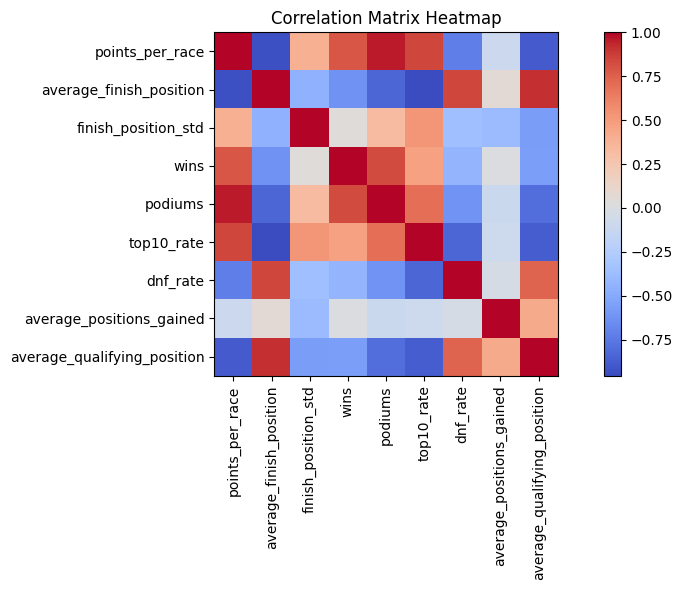

In [20]:
import matplotlib.pyplot as plt

output_path = r"C:\Users\richy\Downloads\F1_Index\outputs\correlation_heatmap.png"

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()

plt.savefig(output_path, dpi=300)

plt.show()

## 9.2 PCA - STANDARDISATION

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.64808862e-01, -2.28911848e-01,  2.94669581e-01,
        -3.48491885e-01, -3.97647357e-01,  6.43871365e-01,
         4.85023978e-01,  4.04056777e-01,  1.51864663e-03],
       [ 9.90840529e-01, -8.78615439e-01,  1.90798035e+00,
        -3.05694636e-03,  1.56454266e+00,  6.43871365e-01,
        -6.29667574e-01, -1.04622900e+00, -1.56836020e+00],
       [ 7.80009416e-02, -3.70547231e-01,  1.05234796e+00,
        -3.48491885e-01, -3.97647357e-01,  6.43871365e-01,
         1.13460128e-01, -1.75782626e+00, -9.06912701e-01],
       [-8.18074085e-01,  5.98030881e-01, -1.69203849e+00,
        -3.48491885e-01, -5.93866359e-01, -1.16154751e+00,
         1.78345590e+00, -1.16095532e-01,  6.62966149e-01],
       [ 2.38506253e+00, -1.91814118e+00,  2.37739050e-01,
         2.41498762e+00,  2.74185667e+00,  1.33732328e+00,
        -1.37279528e+00, -1.43186798e-01, -1.92395612e+00]])

## PCA MODEL

In [22]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(len(feature_cols))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance.round(3)

,Component,Explained Variance,Cumulative Variance
0,PC1,0.656,0.656
1,PC2,0.157,0.813
2,PC3,0.100,0.913
3,PC4,0.049,0.962
4,PC5,0.020,0.981
5,PC6,0.013,0.994
6,PC7,0.004,0.998
7,PC8,0.001,0.999
8,PC9,0.001,1.000


## SCREE PLOT

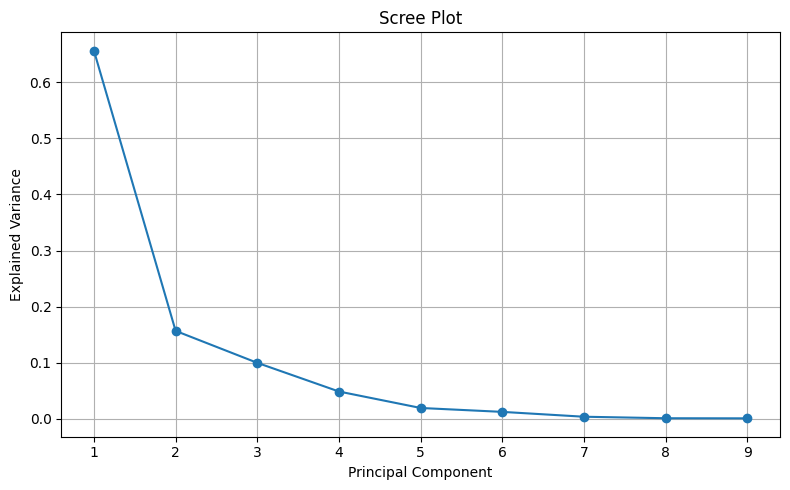

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(feature_cols)+1), pca.explained_variance_ratio_, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.xticks(range(1, len(feature_cols)+1))
plt.grid()
plt.tight_layout()

plt.savefig(r"C:\Users\richy\Downloads\F1_Index\outputs\scree_plot.png", dpi=300)

plt.show()

## PCA SCATTER PLOT


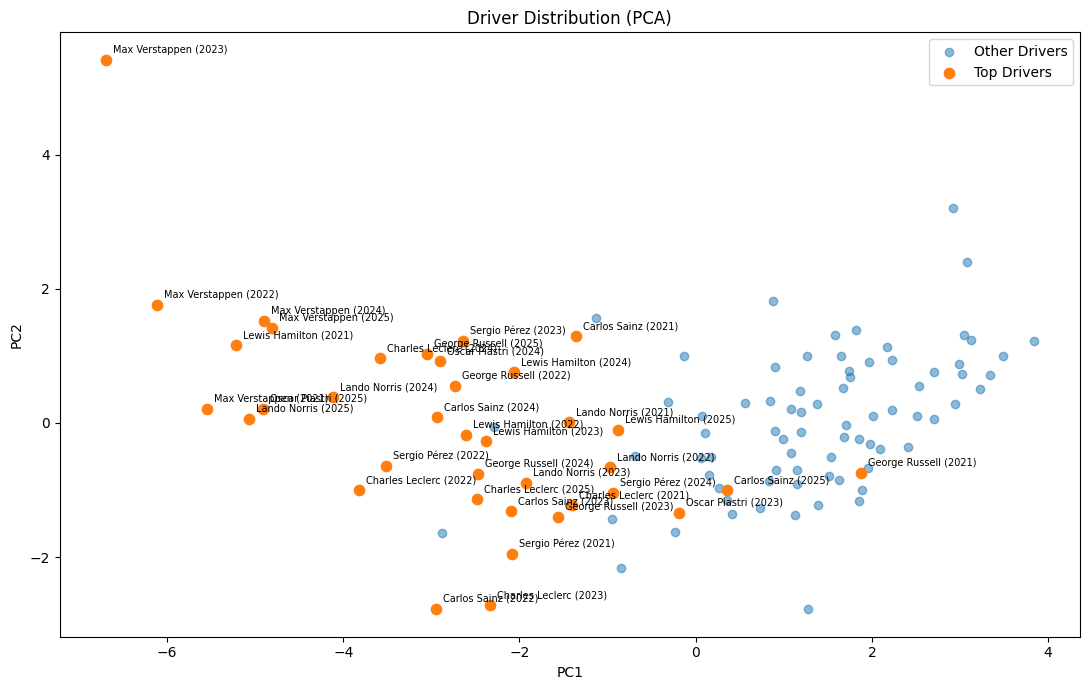

In [ ]:
pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["driver_name"] = driver_season_df["driver_name"]
pca_df["season"] = driver_season_df["season"]
pca_df["points_per_race"] = driver_season_df["points_per_race"]

top_drivers = (
    driver_season_df
    .sort_values("points_per_race", ascending=False)["driver_name"]
    .unique()[:8]
)

pca_df["group"] = pca_df["driver_name"].apply(
    lambda x: "Top Driver" if x in top_drivers else "Other Drivers"
)

plt.figure(figsize=(11, 7))

others = pca_df[pca_df["group"] == "Other Drivers"]
plt.scatter(
    others["PC1"],
    others["PC2"],
    alpha=0.5,
    label="Other Drivers"
)

tops = pca_df[pca_df["group"] == "Top Driver"]
plt.scatter(
    tops["PC1"],
    tops["PC2"],
    s=55,
    label="Top Drivers"
)

label_df = (
    pca_df.sort_values(["PC1", "points_per_race"], ascending=[True, False])
    .head(4)
)

label_df = pd.concat([
    label_df,
    pca_df.sort_values("PC1", ascending=False).head(4)
]).drop_duplicates()

for _, row in tops.iterrows():
    plt.annotate(
        f"{row['driver_name']} ({row['season']})",
        (row["PC1"], row["PC2"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=7
    )

plt.title("Driver Distribution (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()

plt.savefig(
    r"C:\Users\richy\Downloads\F1_Index\outputs\pca_driver_distribution_clean.png",
    dpi=300
)

plt.show()

## 10.1 K-MEANS CLUSTERING

In [25]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

driver_season_df["cluster"] = clusters

driver_season_df.head()

,season,driver_id,driver_code,driver_name,constructor,races,total_points,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_finishes,dnfs,dnf_rate,average_positions_gained,top10_rate,podium_rate,win_rate,average_qualifying_position,cluster
0,2021,alonso,ALO,Fernando Alonso,Alpine F1 Team,22,81.0,3.682,9.909,4.418,0,1,15,11,0.500,0.591,0.682,0.045,0.000,11.000,2
1,2021,bottas,BOT,Valtteri Bottas,Mercedes,22,219.0,9.955,7.409,6.345,1,11,15,5,0.227,-1.818,0.682,0.500,0.045,3.773,2
2,2021,gasly,GAS,Pierre Gasly,AlphaTauri,22,110.0,5.000,9.364,5.323,0,1,15,9,0.409,-3.000,0.682,0.045,0.000,6.818,2
3,2021,giovinazzi,GIO,Antonio Giovinazzi,Alfa Romeo,22,3.0,0.136,13.091,2.045,0,0,2,18,0.818,-0.273,0.091,0.000,0.000,14.045,0
4,2021,hamilton,HAM,Lewis Hamilton,Mercedes,22,385.5,17.523,3.409,4.350,8,17,20,1,0.045,-0.318,0.909,0.773,0.364,2.136,1


## CLUSTER VISUALISATION


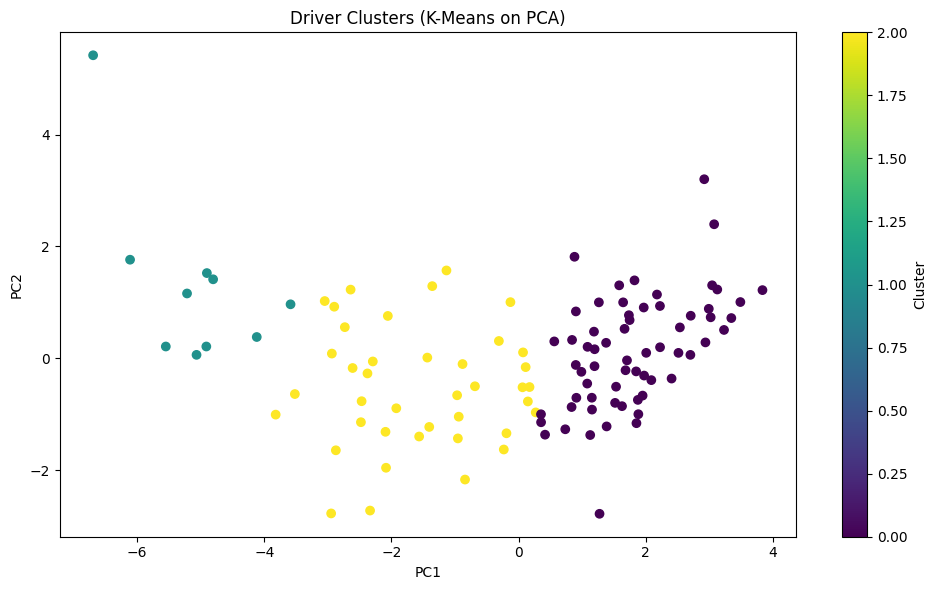

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=driver_season_df["cluster"],
    cmap='viridis'
)

plt.title("Driver Clusters (K-Means on PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster")

plt.tight_layout()

plt.savefig(r"C:\Users\richy\Downloads\F1_Index\outputs\driver_clusters.png", dpi=300)

plt.show()

In [27]:
driver_season_df.groupby("cluster")["points_per_race"].mean()

cluster
0     0.805397
1    17.203800
2     7.359450
Name: points_per_race, dtype: float64

## CHECK CLUSTERS ACROSS ALL SEASONS

In [28]:
cluster_means = driver_season_df.groupby("cluster")["points_per_race"].mean().sort_values()
print("Cluster mean points per race:")
print(cluster_means)
print()

cluster_labels = {
    cluster_means.index[0]: "Lower Grid",
    cluster_means.index[1]: "Midfield",
    cluster_means.index[2]: "Elite"
}

driver_season_df["cluster_label"] = driver_season_df["cluster"].map(cluster_labels)

cluster_season_table = (
    driver_season_df
    .groupby(["season", "cluster_label"])
    .size()
    .unstack(fill_value=0)
)

print("Cluster counts by season:")
print(cluster_season_table)
print()

cluster_summary = (
    driver_season_df
    .groupby("cluster_label")["points_per_race"]
    .describe()
    .round(3)
)

print("Cluster summary statistics:")
print(cluster_summary)
print()

preview_df = (
    driver_season_df[["driver_name", "season", "points_per_race", "cluster", "cluster_label"]]
    .sort_values(["season", "cluster_label", "driver_name"])
    .reset_index(drop=True)
)

print("Preview of labelled driver-season rows:")
display(preview_df.head(30))

Cluster mean points per race:
cluster
0     0.805397
2     7.359450
1    17.203800
Name: points_per_race, dtype: float64

Cluster counts by season:
cluster_label  Elite  Lower Grid  Midfield
season                                    
2021               2          10         9
2022               1          12         9
2023               1          10        11
2024               3          15         7
2025               3          16         4

Cluster summary statistics:
               count    mean    std     min     25%     50%     75%     max
cluster_label                                                              
Elite           10.0  17.204  2.956  13.625  15.958  16.521  17.625  24.091
Lower Grid      63.0   0.805  0.738   0.000   0.152   0.636   1.339   2.917
Midfield        40.0   7.359  3.269   2.000   4.761   7.352   9.887  13.227

Preview of labelled driver-season rows:


,driver_name,season,points_per_race,cluster,cluster_label
0,Lewis Hamilton,2021,17.523,1,Elite
1,Max Verstappen,2021,17.659,1,Elite
2,Antonio Giovinazzi,2021,0.136,0,Lower Grid
3,George Russell,2021,0.727,0,Lower Grid
4,Kimi Räikkönen,2021,0.500,0,Lower Grid
5,Lance Stroll,2021,1.545,0,Lower Grid
6,Mick Schumacher,2021,0.000,0,Lower Grid
7,Nicholas Latifi,2021,0.318,0,Lower Grid
8,Nikita Mazepin,2021,0.000,0,Lower Grid
9,Robert Kubica,2021,0.000,0,Lower Grid


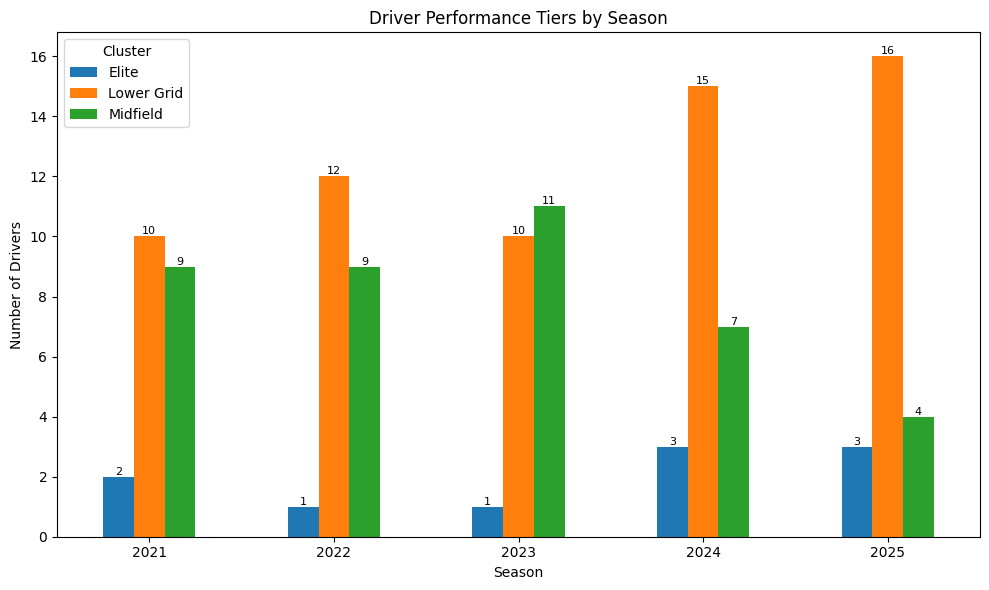

In [29]:
import matplotlib.pyplot as plt

ax = cluster_season_table.plot(kind="bar", figsize=(10,6))

for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=8)

plt.title("Driver Performance Tiers by Season")
plt.xlabel("Season")
plt.ylabel("Number of Drivers")
plt.xticks(rotation=0)
plt.legend(title="Cluster")

plt.tight_layout()

plt.savefig(
    r"C:\Users\richy\Downloads\F1_Index\outputs\cluster_distribution_by_season.png",
    dpi=300
)

plt.show()

## 11. NORMALISATION

In [30]:
index_features = [
    "points_per_race",
    "average_finish_position",
    "finish_position_std",
    "wins",
    "podiums",
    "top10_rate",
    "dnf_rate",
    "average_positions_gained",
    "average_qualifying_position"
]

In [31]:
norm_df = driver_season_df.copy()

norm_df["average_finish_position"] = -norm_df["average_finish_position"]
norm_df["average_qualifying_position"] = -norm_df["average_qualifying_position"]
norm_df["dnf_rate"] = -norm_df["dnf_rate"]
norm_df["finish_position_std"] = -norm_df["finish_position_std"]

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

norm_df[index_features] = scaler.fit_transform(norm_df[index_features])

In [33]:
norm_df[index_features].head()

,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_rate,dnf_rate,average_positions_gained,average_qualifying_position
0,0.152837,0.479477,0.448343,0.000000,0.047619,0.682,0.500,0.60728,0.503807
1,0.413225,0.630161,0.161885,0.052632,0.523810,0.682,0.773,0.41456,0.908363
2,0.207546,0.512326,0.313810,0.000000,0.047619,0.682,0.591,0.32000,0.737909
3,0.005645,0.287686,0.801100,0.000000,0.000000,0.091,0.182,0.53816,0.333352
4,0.727367,0.871255,0.458451,0.421053,0.809524,0.909,0.955,0.53456,1.000000


## 12.1 DRIVER PERFORMANCE INDEX (DPI)

In [34]:
norm_features = [
    "points_per_race",
    "average_finish_position",
    "finish_position_std",
    "wins",
    "podiums",
    "top10_rate",
    "dnf_rate",
    "average_positions_gained",
    "average_qualifying_position"
]

weight = 1 / len(norm_features)

norm_df["DPI"] = norm_df[norm_features].sum(axis=1) * weight

norm_df[["driver_name", "season", "DPI"]].head()

,driver_name,season,DPI
0,Fernando Alonso,2021,0.380151
1,Valtteri Bottas,2021,0.506626
2,Pierre Gasly,2021,0.379134
3,Antonio Giovinazzi,2021,0.248771
4,Lewis Hamilton,2021,0.742912


## DRIVER RANKING


In [35]:
norm_df["DPI_rank"] = norm_df["DPI"].rank(ascending=False)

norm_df.sort_values("DPI", ascending=False).head(10)

,season,driver_id,driver_code,driver_name,constructor,races,total_points,points_per_race,average_finish_position,finish_position_std,wins,podiums,top10_finishes,dnfs,dnf_rate,average_positions_gained,top10_rate,podium_rate,win_rate,average_qualifying_position,cluster,cluster_label,DPI,DPI_rank
53,2023,max_verstappen,VER,Max Verstappen,Red Bull,22,530.0,1.000000,1.000000,0.973837,1.000000,1.000000,22,0,1.000,0.71272,1.000,0.955,0.864,0.951635,1,Elite,0.959799,1.0
31,2022,max_verstappen,VER,Max Verstappen,Red Bull,22,433.0,0.816986,0.865771,0.325554,0.789474,0.809524,20,2,0.909,0.55272,0.909,0.773,0.682,0.974530,1,Elite,0.772506,2.0
4,2021,hamilton,HAM,Lewis Hamilton,Mercedes,22,385.5,0.727367,0.871255,0.458451,0.421053,0.809524,20,1,0.955,0.53456,0.909,0.773,0.364,1.000000,1,Elite,0.742912,3.0
78,2024,max_verstappen,VER,Max Verstappen,Red Bull,24,399.0,0.690092,0.858236,0.533819,0.473684,0.666667,23,1,0.958,0.55336,0.958,0.583,0.375,0.956281,1,Elite,0.738682,4.0
104,2025,max_verstappen,VER,Max Verstappen,Red Bull,24,389.0,0.672782,0.855705,0.522521,0.421053,0.714286,23,1,0.958,0.55336,0.958,0.625,0.333,0.923645,1,Elite,0.731039,5.0
8,2021,max_verstappen,VER,Max Verstappen,Red Bull,22,388.5,0.733012,0.827437,0.190724,0.526316,0.857143,19,3,0.864,0.45816,0.864,0.818,0.455,0.961823,1,Elite,0.698068,6.0
107,2025,piastri,PIA,Oscar Piastri,McLaren,24,381.0,0.658960,0.823097,0.329567,0.368421,0.761905,22,2,0.917,0.46336,0.917,0.667,0.292,0.949283,1,Elite,0.687621,7.0
105,2025,norris,NOR,Lando Norris,McLaren,24,394.0,0.681458,0.820565,0.271889,0.368421,0.857143,21,3,0.875,0.45664,0.875,0.750,0.292,0.953986,1,Elite,0.684456,8.0
79,2024,norris,NOR,Lando Norris,McLaren,24,344.0,0.594952,0.818034,0.498588,0.210526,0.619048,23,1,0.958,0.48664,0.958,0.542,0.167,0.921294,1,Elite,0.673898,9.0
108,2025,russell,RUS,George Russell,Mercedes,24,289.0,0.499855,0.802965,0.733165,0.105263,0.428571,23,1,0.958,0.54664,0.958,0.375,0.083,0.874664,2,Midfield,0.656347,10.0


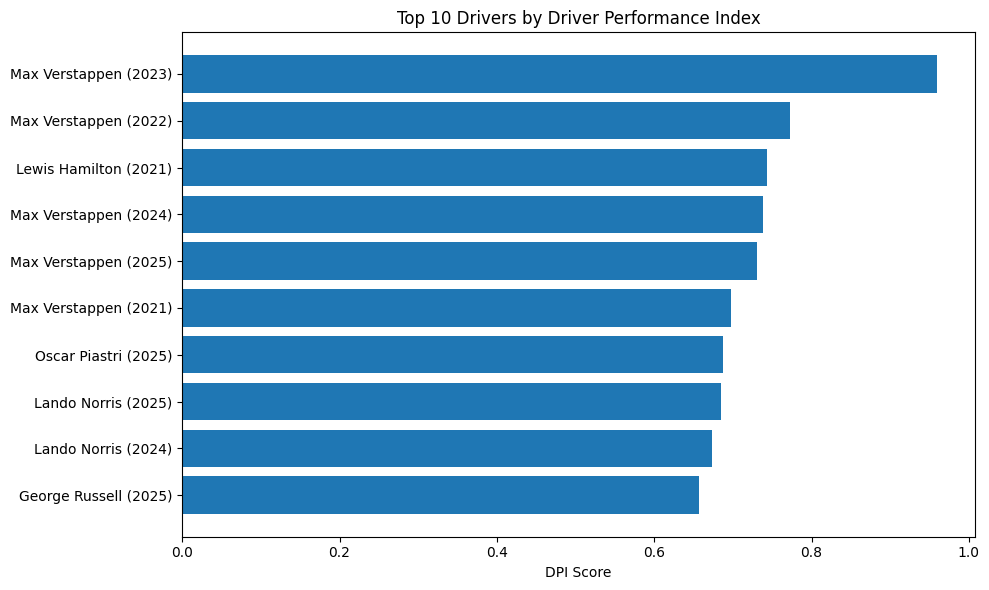

In [36]:
top10 = norm_df.sort_values("DPI", ascending=False).head(10)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top10["driver_name"] + " (" + top10["season"].astype(str) + ")",
    top10["DPI"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Drivers by Driver Performance Index")
plt.xlabel("DPI Score")

plt.tight_layout()

plt.savefig(
    r"C:\Users\richy\Downloads\F1_Index\outputs\top10_dpi.png",
    dpi=300
)

plt.show()

## OFFICIAL STANDINGS RANK

In [38]:
norm_df["official_rank"] = (
    norm_df.groupby("season")["total_points"]
    .rank(ascending=False, method="dense")
)

norm_df["DPI_rank_season"] = (
    norm_df.groupby("season")["DPI"]
    .rank(ascending=False, method="dense")
)

In [39]:
norm_df["rank_difference"] = norm_df["official_rank"] - norm_df["DPI_rank_season"]

comparison_df = norm_df[
    ["season", "driver_name", "constructor", "official_rank", "DPI_rank_season", "rank_difference"]
]

comparison_df.head(20)

,season,driver_name,constructor,official_rank,DPI_rank_season,rank_difference
0,2021,Fernando Alonso,Alpine F1 Team,10.0,9.0,1.0
1,2021,Valtteri Bottas,Mercedes,3.0,5.0,-2.0
2,2021,Pierre Gasly,AlphaTauri,9.0,10.0,-1.0
3,2021,Antonio Giovinazzi,Alfa Romeo,18.0,15.0,3.0
4,2021,Lewis Hamilton,Mercedes,2.0,1.0,1.0
5,2021,Robert Kubica,Alfa Romeo,19.0,13.0,6.0
6,2021,Nicholas Latifi,Williams,17.0,19.0,-2.0
7,2021,Charles Leclerc,Ferrari,7.0,7.0,0.0
8,2021,Max Verstappen,Red Bull,1.0,2.0,-1.0
9,2021,Nikita Mazepin,Haas F1 Team,19.0,21.0,-2.0


## DPI RANK VS OFFICIAL STANDINGS


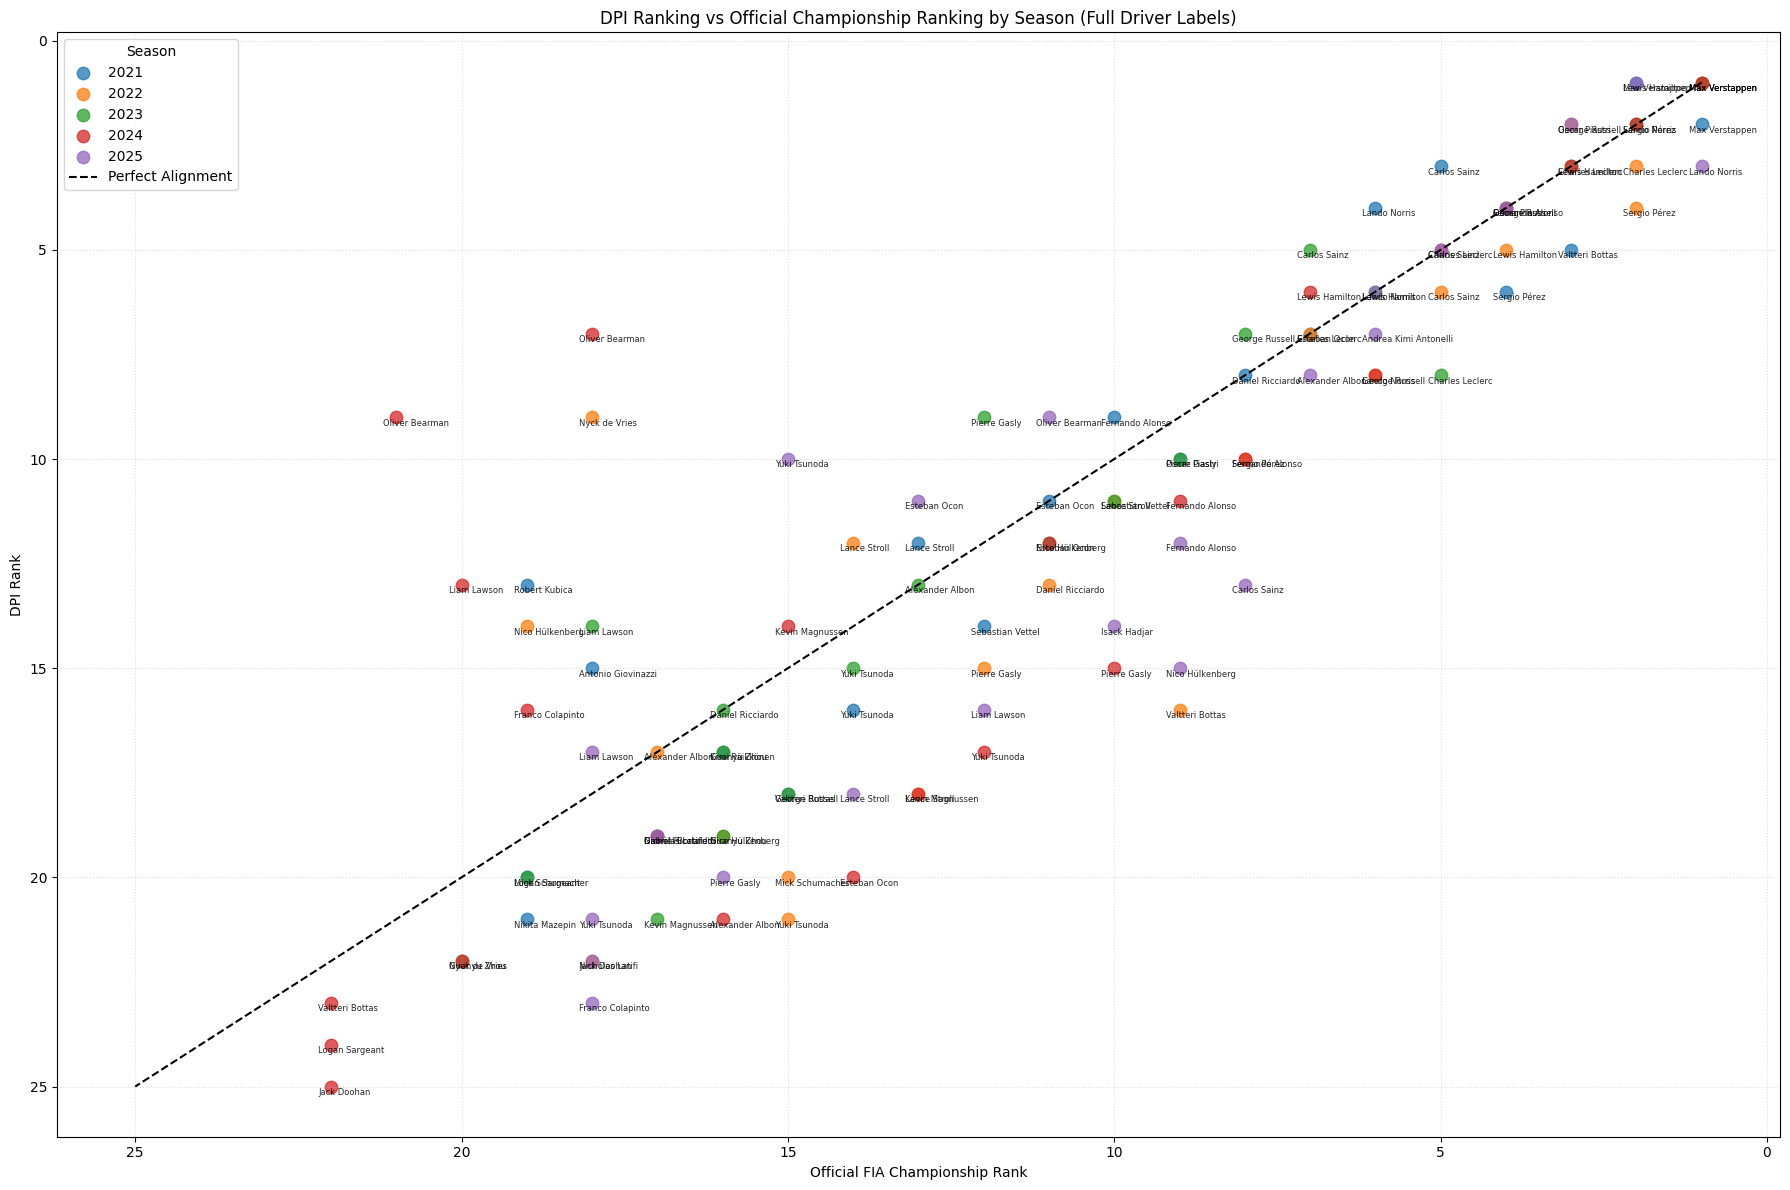

In [45]:
fig, ax = plt.subplots(figsize=(18, 12))

for season in sorted(comparison_df["season"].unique()):
    season_data = comparison_df[comparison_df["season"] == season]

    ax.scatter(
        season_data["official_rank"],
        season_data["DPI_rank_season"],
        label=str(season),
        alpha=0.75,
        s=80
    )

    for _, row in season_data.iterrows():
        ax.text(
            row["official_rank"] + 0.2,
            row["DPI_rank_season"] + 0.2,
            row["driver_name"],
            fontsize=6,
            alpha=0.85
        )

max_rank = int(max(
    comparison_df["official_rank"].max(),
    comparison_df["DPI_rank_season"].max()
))

ax.plot(
    [1, max_rank],
    [1, max_rank],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="Perfect Alignment"
)

ax.invert_xaxis()
ax.invert_yaxis()

ax.set_title("DPI Ranking vs Official Championship Ranking by Season (Full Driver Labels)")
ax.set_xlabel("Official FIA Championship Rank")
ax.set_ylabel("DPI Rank")

ax.grid(True, linestyle=":", alpha=0.4)

ax.legend(title="Season")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "dpi_vs_official_rank_full_names.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()